# Preprocessing
For this jupyter, we will be going through the preprocessing steps necessary to prepare the data for corrca

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np

# Resolve repository root and source file path robustly from notebook location
repo_root = next(p for p in Path.cwd().resolve().parents if (p / 'pyproject.toml').exists())
BDF_PATH = repo_root / 'data' / 'phd_data' / 'solo1_A_1.bdf'

# mapping from trigger codes to descriptive names
ID_TO_NAME = {
    1: 'exp_start',
    2: 'exp_end',
    3: 'welcome',
    4: 'instruction',
    5: 'fixation_cross',
    10: 'video0_start',
    40: 'video3_start',
    50: 'video4_start',
    60: 'video5_start',
    70: 'video6_start',
    80: 'video7_start',
    90: 'video8_start',
    100: 'video9_start',
    110: 'video10_start',
    130: 'video0_end',
    160: 'video3_end',
    170: 'video4_end',
    180: 'video5_end',
    190: 'video6_end',
    200: 'video7_end',
    210: 'video8_end',
    220: 'video9_end',
    230: 'video10_end',
}

START_END_MAP = {
    10: 130,
    40: 160,
    50: 170,
    60: 180,
    70: 190,
    80: 200,
    90: 210,
    100: 220,
    110: 230,
}

# Load BDF with preload for filtering/ICA
raw = mne.io.read_raw_bdf(BDF_PATH, preload=True)
print(raw)

# Set BioSemi 64 montage for topography
montage = mne.channels.make_standard_montage('biosemi64')
raw.set_montage(montage, on_missing='ignore')
scalp_eeg_names = [ch for ch in montage.ch_names if ch in raw.ch_names]

Extracting BDF parameters from /home/bjorn_dev/bachelor_eeg_engagement/data/phd_data/solo1_A_1.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 4167679  =      0.000 ...  2035.000 secs...
<RawBDF | solo1_A_1.bdf, 80 x 4167680 (2035.0 s), ~2.48 GiB, data loaded>


In [7]:
# Filtering: 1 Hz high-pass, 100 Hz low-pass, notch at 50 Hz
raw.filter(l_freq=1.0, h_freq=100.0, picks='eeg', verbose='ERROR') # Bandpass
raw.notch_filter(freqs=[50.0], picks='eeg', verbose='ERROR')

# Create epochs from each video_start to its matching video_end
video_epochs_data = []
video_epoch_names = []

# Extract events from the BDF status trigger channel
events = mne.find_events(raw, stim_channel='Status', shortest_event=1, initial_event=True)
print(f'Found {len(events)} total trigger events')

for start_id, end_id in START_END_MAP.items():
    start_events = events[events[:, 2] == start_id]
    if len(start_events) == 0:
        continue
    for start_event in start_events:
        start_sample = start_event[0]
        end_candidates = events[(events[:, 0] > start_sample) & (events[:, 2] == end_id)]
        if len(end_candidates) == 0:
            continue
        end_sample = end_candidates[0][0]
        if end_sample <= start_sample:
            continue
        seg = raw.copy().crop(
            tmin=start_sample / raw.info['sfreq'],
            tmax=end_sample / raw.info['sfreq'],
            include_tmax=False,
        )
        video_epochs_data.append(seg.get_data())
        video_epoch_names.append(ID_TO_NAME.get(start_id, f'code_{start_id}'))

print(f'Constructed {len(video_epochs_data)} variable-length video epochs')

# Downsample to 256 Hz after epoch (?)
raw.resample(256)
video_epochs_data = [mne.filter.resample(epoch, down=raw.info['sfreq'] / 256) for epoch in video_epochs_data]
print(f'Sampling rate after downsampling: {raw.info["sfreq"]} Hz')

Finding events on: Status
29 events found on stim channel Status
Event IDs: [    4     5    10    40    50    60    70    80    90   100   110   130
   160   170   180   190   200   210   220   230 65536]
Found 29 total trigger events
Constructed 9 variable-length video epochs
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
28 events found on stim channel Status
Event IDs: [  4   5  10  40  50  60  70  80  90 100 110 130 160 170 180 190 200 210
 220 230]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
28 events found on stim channel Status
Event IDs: [  4   5  10  40  50  60  70  80  90 100 110 130 160 170 180 190 200 210
 220 230]
Sampling rate after downsampling: 256.0 Hz


In [8]:
# Remove channels 65-67 if present
fixed_drop_candidates = ['EXG5', 'EXG6', 'EXG7', '65', '66', '67']
fixed_drop = [ch for ch in fixed_drop_candidates if ch in raw.ch_names]
if fixed_drop:
    raw.drop_channels(fixed_drop)
print(f'Dropped fixed channels (65-67): {fixed_drop}')

# Mark EOG (eyes) channels so ICA can model ocular artifacts
eog_candidates = [ch for ch in ['EXG8', 'EXG9', 'EXG10', '68', '69', '70'] if ch in raw.ch_names]
for ch in eog_candidates:
    raw.set_channel_types({ch: 'eog'})
print(f'EOG channels retained for ICA: {eog_candidates}')

# Update scalp EEG channel list after fixed removals
scalp_eeg_names = [ch for ch in montage.ch_names if ch in raw.ch_names]

Dropped fixed channels (65-67): ['EXG5', 'EXG6', 'EXG7']
EOG channels retained for ICA: ['EXG8']


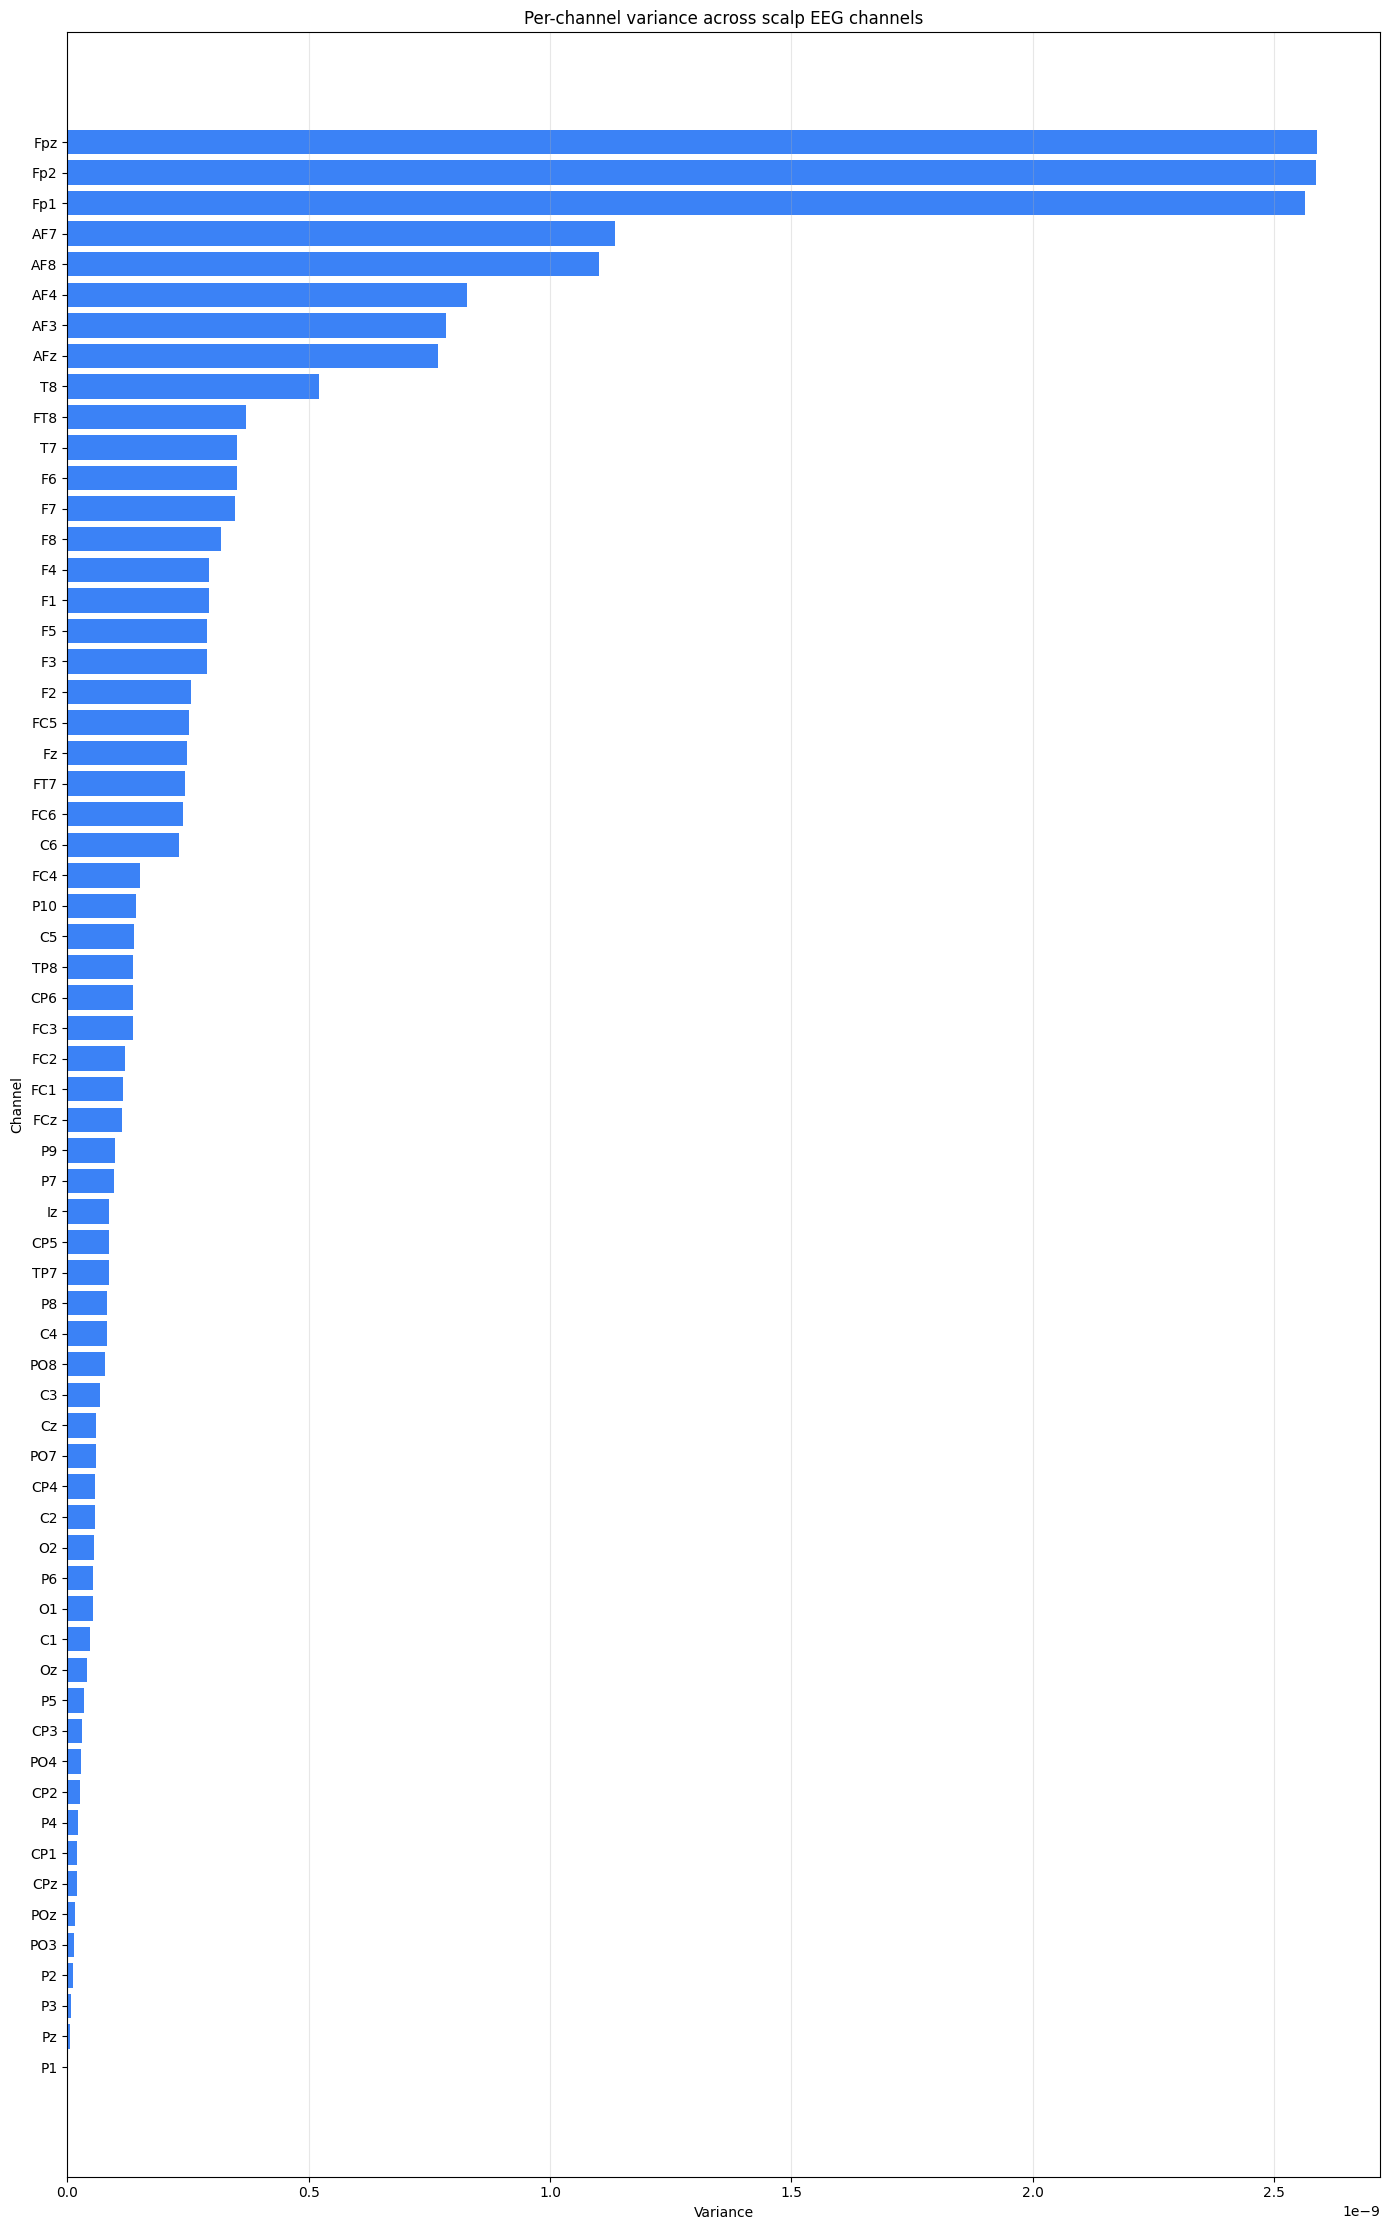

In [ ]:
# Review scalp EEG channels with variance and spectrum summaries
eeg_data = raw.get_data(picks=scalp_eeg_names)
chan_vars = np.var(eeg_data, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].boxplot(
    chan_vars,
    vert=True,
    patch_artist=True,
    boxprops={"facecolor": "#93C5FD", "edgecolor": "#1D4ED8"},
    medianprops={"color": "#1D4ED8", "linewidth": 2},
    whiskerprops={"color": "#1D4ED8"},
    capprops={"color": "#1D4ED8"},
)
axes[0].set_title("Distribution of channel variances")
axes[0].set_ylabel("Variance")
axes[0].set_xticks([1])
axes[0].set_xticklabels(["Scalp EEG"])
axes[0].grid(axis="y", alpha=0.3)

psd = raw.compute_psd(
    method="welch",
    fmin=1.0,
    fmax=45.0,
    picks=scalp_eeg_names,
    n_fft=min(2048, raw.n_times),
)
psd_data, freqs = psd.get_data(return_freqs=True)
psd_db = 10 * np.log10(np.maximum(psd_data, np.finfo(float).tiny))

axes[1].plot(freqs, psd_db.T, color="#94A3B8", alpha=0.25, linewidth=0.8)
axes[1].plot(freqs, psd_db.mean(axis=0), color="#1D4ED8", linewidth=2.0, label="Mean")
axes[1].set_title("Power spectral density")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Power (dB/Hz)")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="upper right")

fig.tight_layout()

In [10]:
# Manually select channels to remove after inspecting the variance plot above.
channels_to_drop = [
    # 'Fp1',
    # 'Fz',
]

channels_to_drop = [ch for ch in channels_to_drop if ch in raw.ch_names]
if channels_to_drop:
    raw.drop_channels(channels_to_drop)
    print(f'Dropped manually selected channels: {channels_to_drop}')
else:
    print('No channels selected for removal.')

# Update scalp list after manual removals
scalp_eeg_names = [ch for ch in montage.ch_names if ch in raw.ch_names]
print(f'Remaining scalp EEG channels for ICA: {len(scalp_eeg_names)}')

# Fit ICA on scalp EEG channels only and inspect first 30 components
ica_n_components = min(30, len(scalp_eeg_names))
ica = mne.preprocessing.ICA(
    n_components=ica_n_components,
    method='fastica',
    random_state=97,
    max_iter='auto',
)
ica.fit(raw, picks=scalp_eeg_names)
#print(ica)


No channels selected for removal.
Remaining scalp EEG channels for ICA: 64
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 30 components
Fitting ICA took 13.9s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,49 iterations on raw data (520960 samples)
ICA components,30
Available PCA components,64
Channel types,eeg
ICA components marked for exclusion,—
